
<h1>Text Classification</h1>


Akhil Kammalan Kandy AK23204


#imports
#pandas for data,nltk for text and sk learn for he AI model. 

In [2]:
import pandas as pd
import nltk
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Downloading the tokenizer tool
nltk.download('punkt')

[nltk_data] Downloading package punkt to /home/akhilkk/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

<h2>Classification of texts</h2>
EKMAN mapping for defining which emotions belong to which basic group. 

In [3]:
ekman_mapping = {
    "anger": ["anger", "annoyance", "disapproval"],
    "disgust": ["disgust"],
    "fear": ["fear", "nervousness"],
    "joy": ["joy", "amusement", "approval", "excitement", "gratitude", "love", "optimism", "relief", "pride", "admiration", "desire", "caring"],
    "sadness": ["sadness", "disappointment", "embarrassment", "grief", "remorse"],
    "surprise": ["surprise", "realization", "confusion", "curiosity"],
    "neutral": ["neutral"]
}

# The original 27 labels in the order they appear in the GoEmotions dataset
goemotions_labels = [
    "admiration", "amusement", "anger", "annoyance", "approval", "caring", 
    "confusion", "curiosity", "desire", "disappointment", "disapproval", 
    "disgust", "embarrassment", "excitement", "fear", "gratitude", 
    "grief", "joy", "love", "nervousness", "optimism", "pride", 
    "realization", "relief", "remorse", "sadness", "surprise", "neutral"
]

# Create a reverse lookup: mapping each of the 27 emotions to its Ekman parent
label_to_ekman = {}
for ekman, fine_list in ekman_mapping.items():
    for fine in fine_list:
        label_to_ekman[fine] = ekman

<h2>Clean and Filter data</h2>
this cell loads the tsv files and removes the sample that has multiple emotions. 

In [4]:
def load_and_map_data(file_path):
    # 1. Read the TSV (Full dataset files have headers and multiple columns)
    df = pd.read_csv(file_path, sep='\t')
    
    # 2. Filter: Only keep rows where exactly one emotion is labeled
    # (GoEmotions full_dataset has 28 columns for individual emotions)
    df['label_count'] = df[goemotions_labels].sum(axis=1)
    df = df[df['label_count'] == 1].copy()
    
    # 3. Identify the emotion label (the column that has the '1')
    df['fine_label'] = df[goemotions_labels].idxmax(axis=1)
    
    # 4. Map the fine label to the 7 Ekman categories
    df['ekman_label'] = df['fine_label'].map(label_to_ekman)
    
    return df[['text', 'ekman_label']]

# Load the files (ensure the paths match where your TSV files are!)
# We use goemotions_1.tsv for training and goemotions_2.tsv for testing
train_df = load_and_map_data('data/full_dataset/goemotions_1.tsv')
test_df = load_and_map_data('data/full_dataset/goemotions_2.tsv')

print(f"Loaded {len(train_df)} training samples and {len(test_df)} test samples.")

Loaded 56984 training samples and 56964 test samples.


<h2>Text Pre-processing</h2>



In [5]:
def clean_text(text):
    #texts are normalized to lowercase, URLs are removed, and numbers are replaced with a placeholder token 'NUMBER'.
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Remove URLs
    text = re.sub(r'\d+', 'NUMBER', text) # Replace numbers with 'NUMBER'
    return text

train_df['clean_text'] = train_df['text'].apply(clean_text)
test_df['clean_text'] = test_df['text'].apply(clean_text)

<h2>Training</h2>

Vectorization of words and feeding to Naive Bayes Model

In [6]:
vectorizer = CountVectorizer(stop_words='english')
X_train = vectorizer.fit_transform(train_df['clean_text'])
y_train = train_df['ekman_label']

# 2. Create and Train the Model
model = MultinomialNB()
model.fit(X_train, y_train)

print("Training Complete!")

Training Complete!


<h2>Evaluation of the model</h2>

The cell shows how well the model predicts the emotions which were not shown before. 
f1 scores are the mean of the precision and recall.


Accuracy: 0.47796854153500457

Classification Report:

              precision    recall  f1-score   support

       anger       0.39      0.21      0.28      7113
     disgust       0.47      0.04      0.07       993
        fear       0.42      0.03      0.05       871
         joy       0.55      0.73      0.63     19497
     neutral       0.42      0.54      0.47     18259
     sadness       0.51      0.17      0.26      3969
    surprise       0.39      0.14      0.21      6262

    accuracy                           0.48     56964
   macro avg       0.45      0.27      0.28     56964
weighted avg       0.46      0.48      0.44     56964



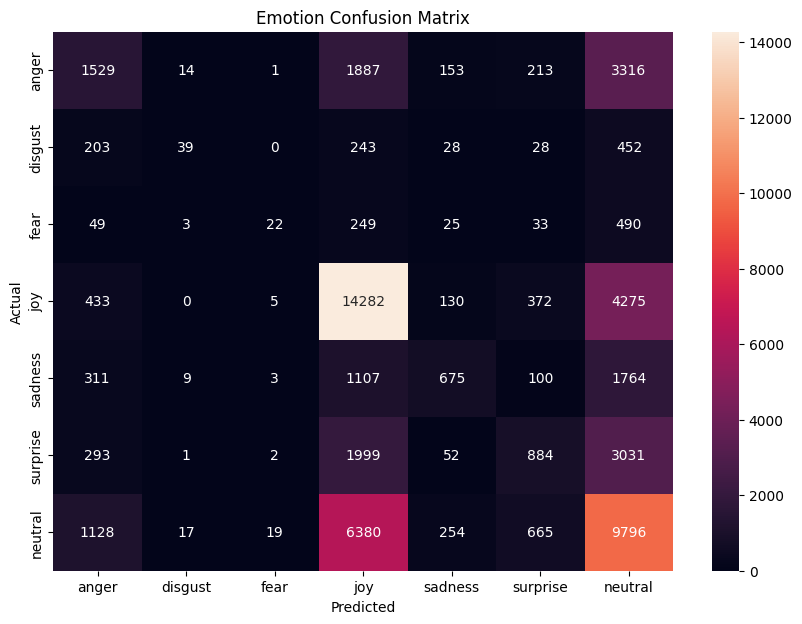

In [9]:
X_test = vectorizer.transform(test_df['clean_text'])
y_test = test_df['ekman_label']

# 2. Predict
y_pred = model.predict(X_test)

# 3. Print Results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# 4. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=list(ekman_mapping.keys()))
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=ekman_mapping.keys(), yticklabels=ekman_mapping.keys())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Emotion Confusion Matrix')
plt.show()

<h1>Documentation</h1>


## Project Overview

This project implements a text emotion classification system using the GoEmotions dataset. The goal is to automatically predict the emotional tone of a given text by mapping 27 fine-grained emotion labels into 7 basic Ekman emotions: anger, disgust, fear, joy, sadness, surprise, and neutral.

### Dataset

- **Source**: GoEmotions dataset containing Reddit comments labeled with emotions
- **Original Labels**: 27 emotions (e.g., admiration, amusement, anger, annoyance, etc.)
- **Simplified Labels**: 7 Ekman basic emotions
- **Preprocessing**: Only samples with exactly one emotion label are retained to maintain class clarity

### Methodology

#### 1. **Emotion Mapping**
The 27 GoEmotions labels are mapped to 7 Ekman basic emotions:
- **Anger**: anger, annoyance, disapproval
- **Disgust**: disgust
- **Fear**: fear, nervousness
- **Joy**: joy, amusement, approval, excitement, gratitude, love, optimism, relief, pride, admiration, desire, caring
- **Sadness**: sadness, disappointment, embarrassment, grief, remorse
- **Surprise**: surprise, realization, confusion, curiosity
- **Neutral**: neutral

#### 2. **Data Cleaning**
Text preprocessing steps:
- Convert text to lowercase for normalization
- Remove URLs (http/https/www patterns)
- Replace numerical values with a 'NUMBER' token
- This ensures the model focuses on semantic meaning rather than specific URLs or numbers

#### 3. **Feature Extraction**
- **Method**: CountVectorizer (Bag-of-Words)
- **Stop Words**: English stop words are removed
- **Output**: Sparse matrix with word frequency counts across all training samples

#### 4. **Classification Model**
- **Algorithm**: Multinomial Naive Bayes
- **Rationale**: Efficient for text classification, works well with sparse feature matrices
- **Training**: Fitted on training set (goemotions_1.tsv)
- **Testing**: Evaluated on separate test set (goemotions_2.tsv)

### Evaluation Metrics

The model performance is evaluated using:
- **Accuracy**: Overall percentage of correct predictions
- **Precision**: Of predicted positive cases, how many were actually positive
- **Recall**: Of actual positive cases, how many were correctly identified
- **F1-Score**: Harmonic mean of precision and recall
- **Confusion Matrix**: Visual representation of prediction patterns across emotion classes

### Results

The confusion matrix and classification report above show how the model performs across different emotion categories. The diagonal values indicate correct predictions, while off-diagonal values show misclassifications between emotion pairs.